# 06 — Progressive Pruning Analysis (Phase 9)

## Objective
Measure whether progressive pruning gives a useful performance/efficiency trade-off, **for each model separately** (5-slice CNN, +SE, +CBAM, +Transformer, +extra-conv control), with two methods, and check whether fewer parameters/FLOPs actually mean faster inference.

## Protocol (fixed before any results)
* Start: each model's trained seed-42 checkpoint (best validation CPM).
* Per level: **prune → fine-tune 4 epochs (AdamW, lr 3e-4, cosine; best-validation epoch kept) → evaluate**; levels are progressive (each starts from the previous).
* **Unstructured**: global magnitude pruning of all conv/linear weights (excl. final output layers) at cumulative sparsity 30/50/70/85/95%; masks only remove weights and are re-applied after every optimizer step.
* **Structured**: whole channels removed and the network physically rebuilt (importance = filter L1 × |BN scale|), 20/40/55/70/80% of channels in stages 1–3 and all inner channels. The last stage output, the Transformer/extra-conv module and the head are **not** pruned (so these two models cannot shrink as far).
* **Control**: the plain CNN fine-tuned for the same 5×4 epochs with *no pruning*.
* **Selection rule (pre-registered, validation only):** the most-pruned level whose validation CPM ≥ the unpruned reference's validation CPM − 0.02. Test results are reported for every level but never used to choose.
* Latency re-measured on an idle machine (median of 3 interleaved rounds) for every checkpoint; unstructured zeros run on dense kernels.

## Configuration

In [1]:
import json
import pandas as pd
from IPython.display import Image, display
T = '../results/tables'; F = '../results/figures'
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 30)
lv = pd.read_csv(f'{T}/phase9_levels.csv')

## All levels (every model, both methods, and the control)

In [2]:
cols = ['model','type','level','target','pre_ft_val_cpm','val_cpm','test_cpm','nonzero_reduction','params_nonzero','flops_effective','lat_cpu_b1','lat_mps_b256']
lv[cols].round(3)

,model,type,level,target,pre_ft_val_cpm,val_cpm,test_cpm,nonzero_reduction,params_nonzero,flops_effective,lat_cpu_b1,lat_mps_b256
0,cbam,structured,0,0.00,NaN,0.794,0.854,0.000,314359,1.108339e+08,2.091,46.212
1,cbam,structured,1,0.20,0.149,0.781,0.823,0.266,230712,7.619365e+07,1.951,40.895
2,cbam,structured,2,0.40,0.202,0.696,0.763,0.492,159762,4.704055e+07,1.665,33.166
3,cbam,structured,3,0.55,0.180,0.694,0.786,0.634,115033,2.896661e+07,1.485,25.454
4,cbam,structured,4,0.70,0.184,0.646,0.657,0.761,75062,1.654223e+07,1.237,20.392
...,...,...,...,...,...,...,...,...,...,...,...,...
61,transformer,unstructured,1,0.30,0.776,0.783,0.852,0.297,400969,8.445637e+07,2.067,30.730
62,transformer,unstructured,2,0.50,0.713,0.766,0.848,0.494,288236,6.217953e+07,2.029,30.739
63,transformer,unstructured,3,0.70,0.407,0.747,0.831,0.692,175503,3.932121e+07,2.017,30.956
64,transformer,unstructured,4,0.85,0.462,0.757,0.808,0.840,90954,2.174510e+07,2.034,30.850


`pre_ft_val_cpm` is validation CPM *immediately after pruning*, before recovery — the damage that fine-tuning repairs.

## Unstructured pruning: accuracy holds, speed does not

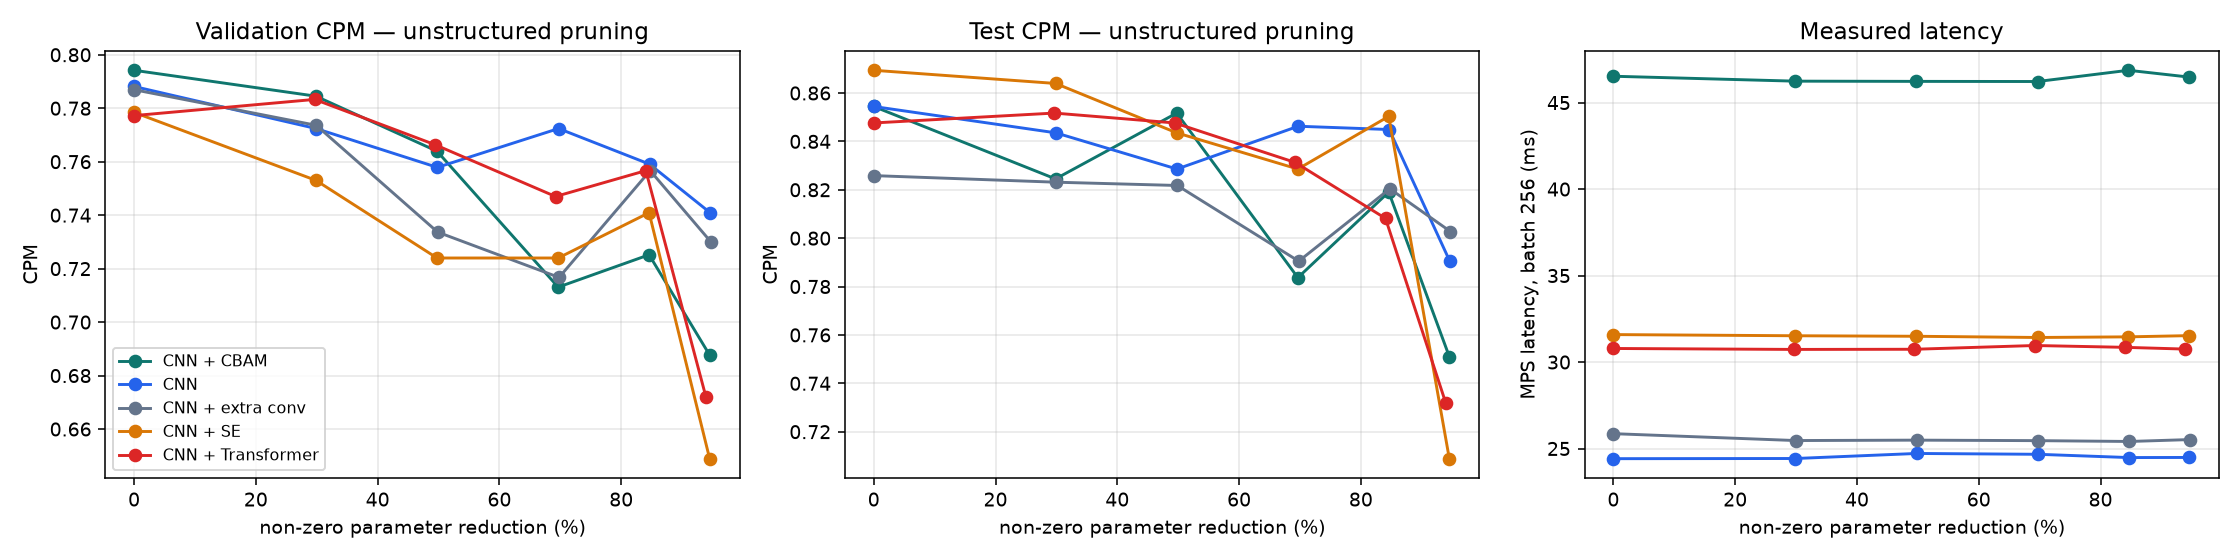

In [3]:
display(Image(f'{F}/phase9_unstructured_tradeoff.png'))

## Structured pruning: real speed-ups, earlier accuracy loss

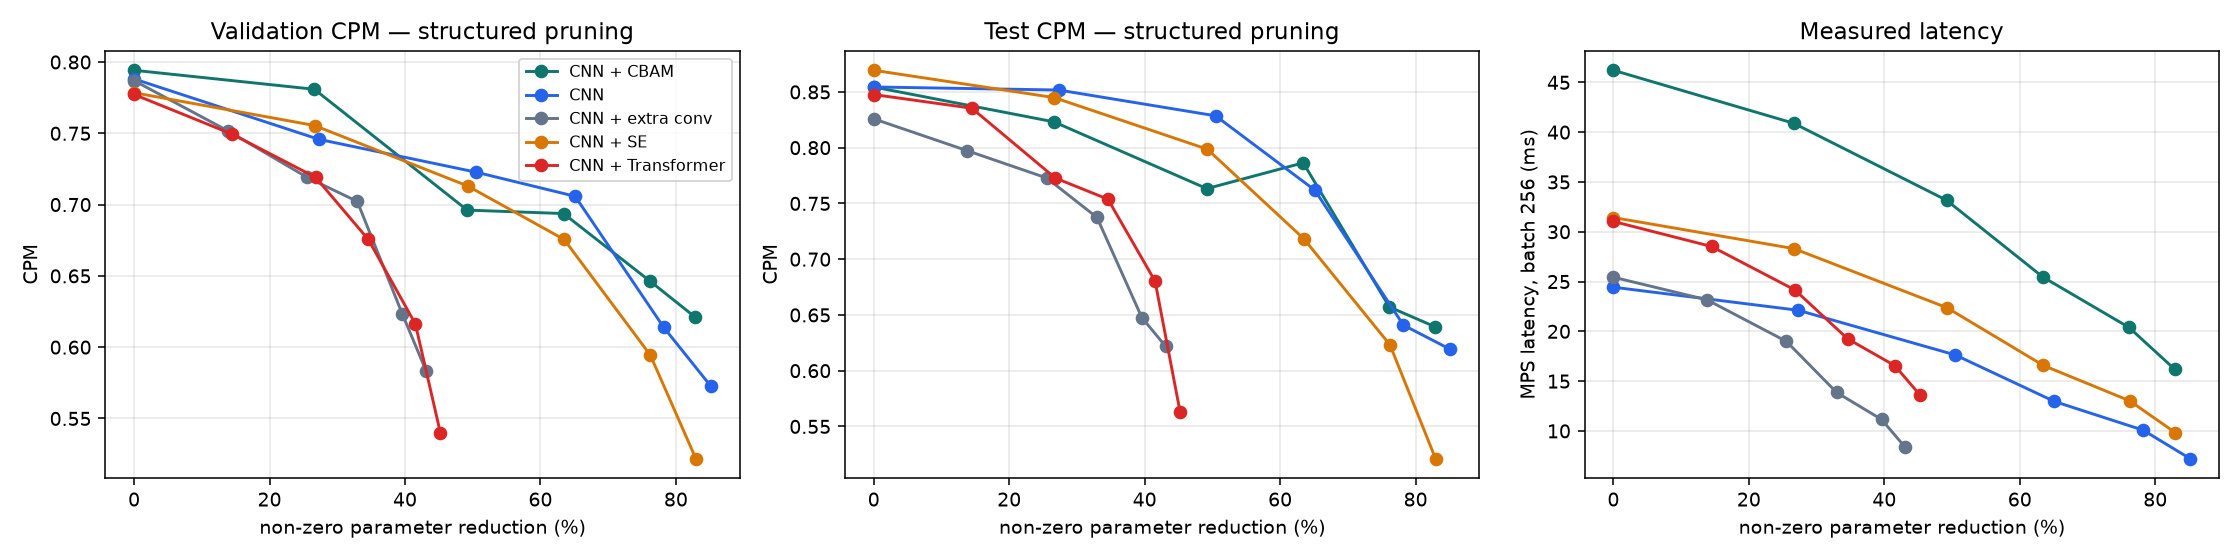

In [4]:
display(Image(f'{F}/phase9_structured_tradeoff.png'))

## Sparsity ≠ speed (plain CNN, both methods)

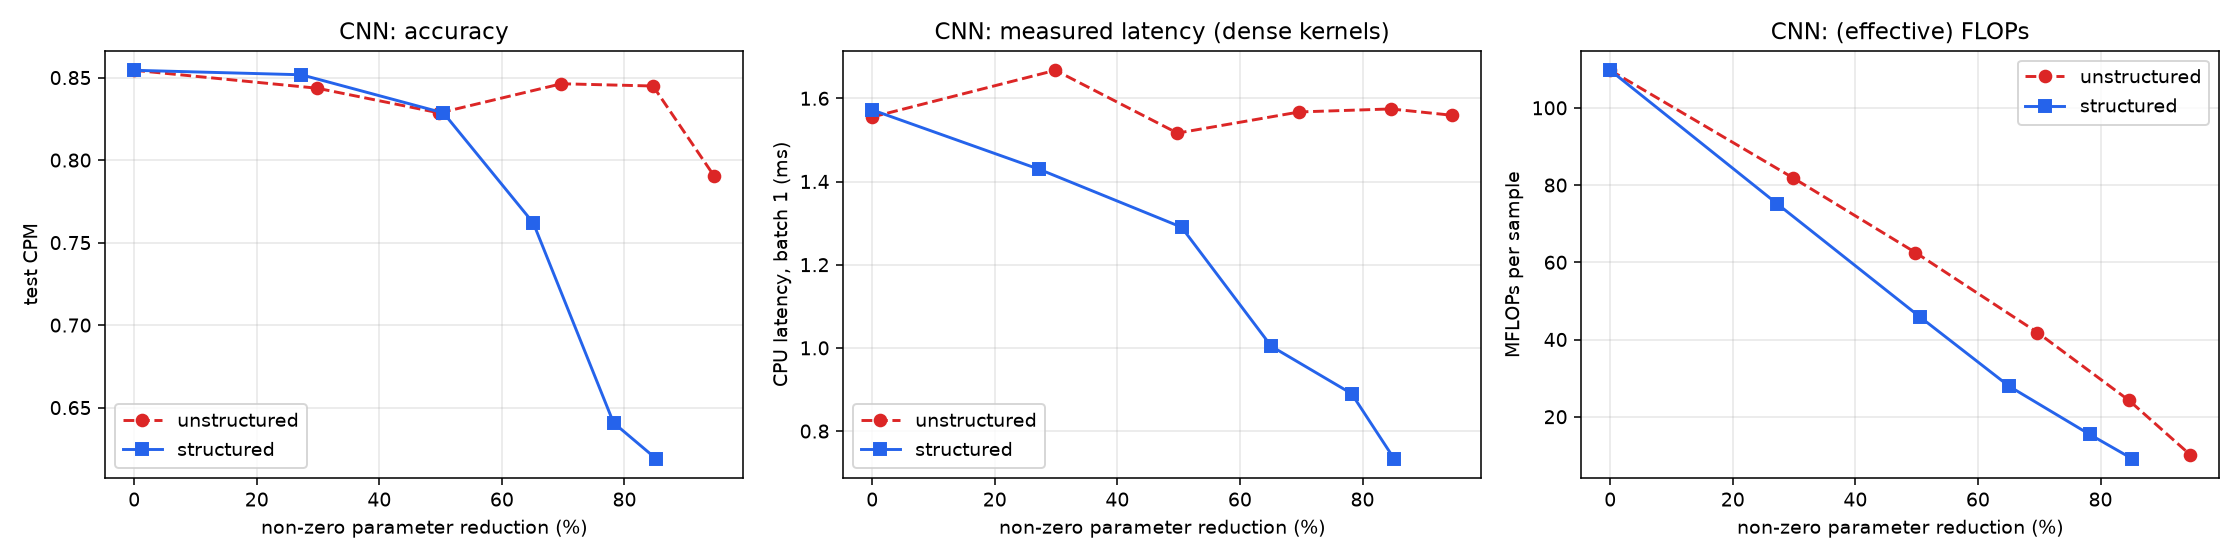

In [5]:
display(Image(f'{F}/phase9_sparsity_vs_speed.png'))

## Pre-registered selection: selected level per model and method (paired bootstrap vs the unpruned reference)

In [6]:
sel = pd.read_csv(f'{T}/phase9_selected.csv')
sel[['model','type','selected_level','target','param_reduction','val_cpm_ref','val_cpm','val_delta_cpm','val_delta_ci_low','val_delta_ci_high','test_cpm_ref','test_cpm','test_delta_cpm','test_delta_ci_low','test_delta_ci_high','lat_cpu_b1_ref','lat_cpu_b1','lat_mps_b256_ref','lat_mps_b256']].round(3)

,model,type,selected_level,target,param_reduction,val_cpm_ref,val_cpm,val_delta_cpm,val_delta_ci_low,val_delta_ci_high,test_cpm_ref,test_cpm,test_delta_cpm,test_delta_ci_low,test_delta_ci_high,lat_cpu_b1_ref,lat_cpu_b1,lat_mps_b256_ref,lat_mps_b256
0,cbam,structured,1.0,0.2,0.266,0.794,0.781,-0.012,-0.051,0.024,0.854,0.823,-0.029,-0.061,0.001,2.091,1.951,46.212,40.895
1,cbam,unstructured,1.0,0.3,0.299,0.794,0.785,-0.011,-0.049,0.024,0.854,0.824,-0.035,-0.064,-0.005,2.157,2.184,46.524,46.240
2,cnn,structured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cnn,unstructured,3.0,0.7,0.697,0.788,0.772,-0.017,-0.043,0.006,0.854,0.846,-0.018,-0.050,0.018,1.555,1.567,24.413,24.666
4,convctrl,structured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,convctrl,unstructured,1.0,0.3,0.299,0.787,0.774,-0.026,-0.057,0.002,0.826,0.823,0.000,-0.031,0.035,1.795,1.883,25.859,25.461
6,se,structured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,se,unstructured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,transformer,structured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,transformer,unstructured,2.0,0.5,0.494,0.777,0.766,-0.014,-0.059,0.019,0.848,0.848,-0.004,-0.047,0.032,2.008,2.029,30.784,30.739


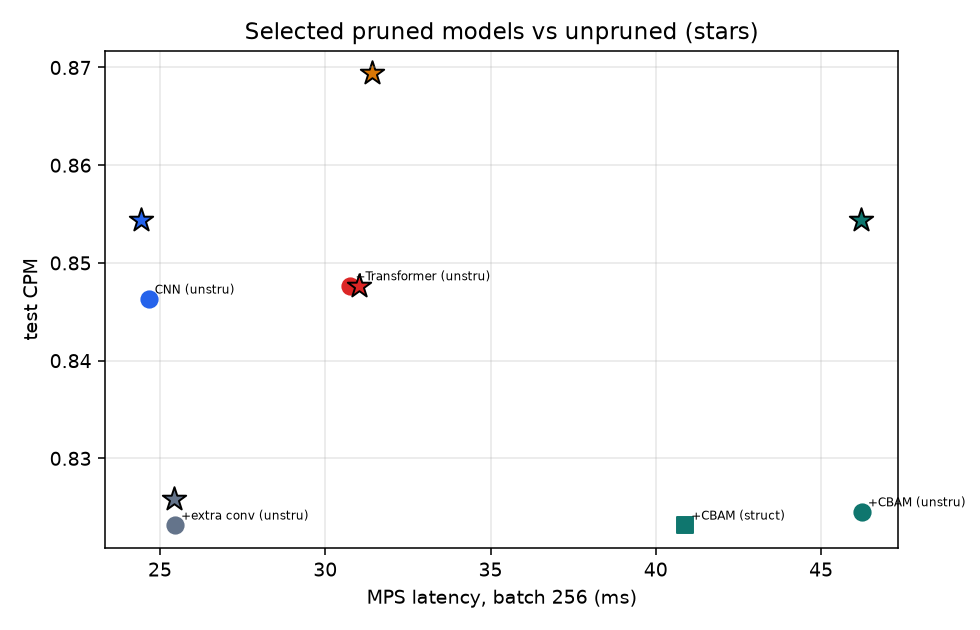

In [7]:
display(Image(f'{F}/phase9_selected_models.png'))

`selected_level` is empty when no level met the rule (SE both methods; CNN, Transformer and extra-conv with structured pruning).

## Post-hoc check (NOT pre-registered): each pruned CNN level vs the no-pruning fine-tune control at the same level
The reference checkpoint is the best of 20 epochs on validation, so it carries a selection advantage that any further training cannot match: the **control itself** drops from 0.788 to 0.783 / 0.776 / 0.781 / 0.755 / 0.753 validation CPM, and would fail the pre-registered rule at levels 4–5. Comparing pruned levels with the control (same extra training, no pruning) isolates the effect of pruning.

In [8]:
pd.read_csv(f'{T}/phase9_vs_control.csv').round(3)

,type,level,target,val_cpm,control_val_cpm,test_cpm,control_test_cpm,nonzero_reduction,val_delta_vs_control,val_delta_ci_low,val_delta_ci_high,test_delta_vs_control,test_delta_ci_low,test_delta_ci_high
0,unstructured,1,0.30,0.772,0.783,0.844,0.833,0.299,-0.007,-0.024,0.009,0.007,-0.008,0.022
1,unstructured,2,0.50,0.758,0.776,0.829,0.822,0.498,-0.030,-0.059,-0.002,0.003,-0.021,0.024
2,unstructured,3,0.70,0.772,0.781,0.846,0.842,0.697,-0.008,-0.030,0.015,0.002,-0.029,0.034
3,unstructured,4,0.85,0.759,0.755,0.845,0.831,0.847,0.012,-0.024,0.050,0.010,-0.026,0.046
4,unstructured,5,0.95,0.741,0.753,0.790,0.824,0.946,-0.014,-0.064,0.034,-0.033,-0.093,0.022
5,structured,1,0.20,0.746,0.783,0.852,0.833,0.273,-0.028,-0.059,0.000,0.007,-0.020,0.037
6,structured,2,0.40,0.723,0.776,0.829,0.822,0.505,-0.059,-0.099,-0.022,0.004,-0.031,0.038
7,structured,3,0.55,0.706,0.781,0.762,0.842,0.651,-0.074,-0.126,-0.023,-0.082,-0.130,-0.032
8,structured,4,0.70,0.614,0.755,0.641,0.831,0.782,-0.138,-0.201,-0.071,-0.199,-0.268,-0.131
9,structured,5,0.80,0.573,0.753,0.619,0.824,0.852,-0.182,-0.250,-0.115,-0.202,-0.278,-0.116


## Findings
1. **Unstructured pruning is almost free in accuracy up to ~85% sparsity and then collapses.** Plain CNN: test CPM 0.854 (dense) → 0.844 / 0.829 / 0.846 / 0.845 at 30 / 50 / 70 / 85% sparsity → 0.790 at 95%. Relative to the fine-tune control, differences are within noise through 85% (val Δ −0.030…+0.012; only 50% sparsity is marginally below the control on validation, CI −0.059…−0.002, while its test Δ is +0.003), and 95% is not significantly different either (val −0.014 [−0.064, +0.034], test −0.033 [−0.093, +0.022]) — but every model's test CPM drops at 95% (CNN 0.790, +SE 0.709, +CBAM 0.751, +Transformer 0.732, +extra conv 0.803). Validation CPM drifts down gradually for all models and fluctuates ±0.02–0.03 between neighbouring levels (e.g. CNN 0.758 at 50% vs 0.772 at 70%), so single levels should not be over-read.
2. **Sparsity ≠ speed (measured).** At 95% sparsity the plain CNN has 16k non-zero weights (−95%) and an *effective* 10 MFLOPs (vs 110) yet identical latency: 24.4 ms MPS (batch 256) and ~1.6 ms CPU (batch 1) — dense kernels still multiply the zeros. The theoretical savings would need sparse kernels/hardware that this pipeline does not use.
3. **Structured pruning delivers measured speed-ups but costs accuracy sooner.** Plain CNN (non-zero parameter reduction → MPS batch-256 / CPU batch-1 latency, vs 24.4 ms / 1.57 ms dense): −27% → 22.1 ms (−9%) / 1.43 ms (−9%); −50% → 17.6 ms (−28%) / 1.29 ms (−18%); −65% → 13.0 ms (−47%) / 1.00 ms (−36%); −78% → 10.1 ms (−59%) / 0.89 ms (−43%); −85% → 7.2 ms (−70%) / 0.73 ms (−53%). Test CPM 0.852 / 0.829 / 0.762 / 0.641 / 0.619 (levels 1–5). Versus the fine-tune control the loss is clear from 55% of channels (test Δ −0.082 [−0.130, −0.032], then −0.199, −0.202); at 20–40% validation and test disagree (val Δ −0.028 / −0.059, test Δ +0.007 / +0.004), i.e. a small loss of up to a few CPM points that the data cannot resolve.
4. **Models differ mainly in how far structured pruning can go.** At the same channel-removal ratio the CNN-family models (CNN, +SE, +CBAM) shrink by 27 / 50 / 65 / 78 / 85% of parameters, but +Transformer and +extra conv only by 14 / 26 / 34 / 41 / 44% because their unpruned 128-wide module holds a large share of the parameters — so at a similar validation CPM (≈0.72) the CNN family has removed about twice as many parameters (≈50% vs ≈26%). +CBAM holds up best at the heaviest structured levels (val 0.646 / 0.621 at 76 / 83% vs CNN 0.614 / 0.573 at 78 / 85%) and has the best level-1 value (0.781). Under unstructured pruning no model is a consistent winner: +Transformer is highest at 30% (0.783 vs CNN 0.772) and 50% (0.766 vs 0.758), the plain CNN at 70% and 85% (0.772, 0.759), and all differences are within the ±0.02–0.03 level-to-level noise.
5. **Pre-registered selection** (validation only): plain CNN unstructured 70% sparsity (val 0.772 vs 0.788; test 0.846 vs 0.854; paired ΔCPM val −0.017 [−0.043, +0.006], test −0.018 [−0.050, +0.018]); +CBAM unstructured 30% and structured 20% channels; +extra conv unstructured 30%; +Transformer unstructured 50%; **no level qualified** for +SE (either method) and for structured CNN / Transformer / extra conv. The rule is stricter than intended (see the control above), which is why it rejects light pruning in several cases; it was kept as pre-registered.
6. **Pruning does not change the Phase 7–8 conclusions:** pruned Transformer/attention variants are not resolvably better than the pruned plain CNN at comparable reduction (mixed, within noise), and they are slower or no smaller; the plain CNN remains the simplest, fastest model with equal-or-similar accuracy.

**Caveats:** one seed (42) per model and method; validation/test sets have 118/105 nodules (bootstrap CI half-widths ≈ 0.03–0.05), so differences under ~0.03 CPM are not resolved; 4 fine-tune epochs per level with one learning rate for all models/methods (not tuned — longer recovery might raise the structured results); structured pruning excludes the last stage and the context module; unstructured speed-ups would need sparse kernels (not evaluated).

**Gate 5:** pruning gives a useful trade-off in two different senses — large *compression* (unstructured, to 70–85% of weights, no resolvable accuracy loss, no speed-up) and real *speed-up* (structured, up to −28% latency at 50% fewer parameters, with a loss that is small at 20–40% channels but unresolved between validation and test). Choosing the final pruned model for Phase 10 is a researcher decision.